# MSCS-634 Project — Consolidated Notebook (Deliverable 4)

**Author:** Saru Bhandari  
**Course:** MSCS-634 – Advanced Big Data and Data Mining  
**Deliverable:** 4 of 4 – Final Insights, Recommendations, and Presentation

This notebook consolidates all code from Deliverables 1-3 into a single,
end-to-end narrative: data cleaning and EDA, regression modeling, and
classification/clustering/pattern mining — followed by a final synthesis,
practical recommendations, and ethical considerations section written
specifically for this deliverable.

**Dataset:** Retail Transactions Dataset — 1,038 raw / 1,000 cleaned retail
purchase transactions across 340 customers, with customer demographics,
product details, and purchase context (see Part 1 for full justification).

---
# Part 1: Data Collection, Cleaning, and Exploration
*(from Deliverable 1)*

## 1. Dataset Selection and Justification

**Dataset:** Retail Transactions Dataset (`retail_transactions_raw.csv`)

**Description:** The dataset contains 750+ individual retail purchase transactions
across 260 customers. Each row is one line-item transaction and includes customer
demographics (age, gender, state, city), product information (category, product
name), purchase details (quantity, unit price, total amount, payment method,
transaction date), and a partially-populated customer satisfaction rating.

**Why this dataset is appropriate for the project:**
- It has **14 attributes** and **750+ records**, exceeding the 8-10 attribute /
  500-record minimum.
- It mixes **numeric** (age, quantity, price, total), **categorical**
  (gender, state, category, payment method), and **datetime** (transaction date)
  fields, which supports the regression, classification, and clustering work in
  later deliverables.
- Because each transaction records a `CustomerID`, `ProductCategory`, and
  `ProductName`, the data can be grouped into **customer/date "baskets"** for
  market-basket / association rule mining (Apriori, FP-Growth) in Deliverable 3.
- It contains **realistic data-quality issues** — missing values, duplicate rows,
  inconsistently formatted state names, and a few extreme outliers — which gives
  genuine cleaning work to perform and document, rather than a dataset that is
  already clean.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set_theme(style="whitegrid")
%matplotlib inline

## 2. Load the Dataset and Inspect Its Structure

In [2]:
df = pd.read_csv("retail_transactions_raw.csv")
print("Shape (rows, columns):", df.shape)
df.head()

Shape (rows, columns): (1038, 14)


,TransactionID,CustomerID,TransactionDate,CustomerAge,Gender,State,City,ProductCategory,ProductName,Quantity,UnitPrice,TotalAmount,PaymentMethod,CustomerSatisfaction
0,T100126,C1157,2025-01-16,49.0,Male,California,Sacramento,Clothing,Running Shoes,3,85.35,256.05,Credit Card,3.0
1,T100956,C1277,2025-03-14,62.0,Male,OH,Cleveland,Beauty,Perfume,1,64.06,64.06,Credit Card,NaN
2,T100798,C1001,2025-04-29,62.0,Female,ny,New York City,Books,Self-Help Guide,5,14.29,71.45,Debit Card,NaN
3,T100438,C1116,2025-10-22,20.0,Female,ga,Augusta,Clothing,Denim Jeans,4,43.67,174.68,Credit Card,NaN
4,T100259,C1030,2025-08-25,43.0,Male,WA,Tacoma,Home & Kitchen,Blender,3,153.32,459.96,PayPal,3.0


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1038 entries, 0 to 1037
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   TransactionID         1038 non-null   str    
 1   CustomerID            1038 non-null   str    
 2   TransactionDate       1038 non-null   str    
 3   CustomerAge           945 non-null    float64
 4   Gender                964 non-null    str    
 5   State                 1038 non-null   str    
 6   City                  1038 non-null   str    
 7   ProductCategory       1038 non-null   str    
 8   ProductName           1038 non-null   str    
 9   Quantity              1038 non-null   int64  
 10  UnitPrice             1038 non-null   float64
 11  TotalAmount           1038 non-null   float64
 12  PaymentMethod         1038 non-null   str    
 13  CustomerSatisfaction  331 non-null    float64
dtypes: float64(4), int64(1), str(9)
memory usage: 113.7 KB


In [4]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
TransactionID,1038,1000,T100113,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CustomerID,1038,326,C1157,9,NaN,NaN,NaN,NaN,NaN,NaN,NaN
TransactionDate,1038,289,2025-06-06,9,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CustomerAge,945.0,NaN,NaN,NaN,45.885714,15.602913,18.0,33.0,46.0,60.0,74.0
Gender,964,2,Female,491,NaN,NaN,NaN,NaN,NaN,NaN,NaN
State,1038,32,Georgia,50,NaN,NaN,NaN,NaN,NaN,NaN,NaN
City,1038,30,Atlanta,49,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ProductCategory,1038,7,Home & Kitchen,196,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ProductName,1038,35,Coffee Maker,45,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Quantity,1038.0,NaN,NaN,NaN,4.878613,13.092531,1.0,2.0,3.0,5.0,195.0


In [5]:
print("Missing values per column:")
print(df.isnull().sum())
print("\nMissing value percentage per column:")
print((df.isnull().sum() / len(df) * 100).round(1))

Missing values per column:
TransactionID             0
CustomerID                0
TransactionDate           0
CustomerAge              93
Gender                   74
State                     0
City                      0
ProductCategory           0
ProductName               0
Quantity                  0
UnitPrice                 0
TotalAmount               0
PaymentMethod             0
CustomerSatisfaction    707
dtype: int64

Missing value percentage per column:
TransactionID            0.0
CustomerID               0.0
TransactionDate          0.0
CustomerAge              9.0
Gender                   7.1
State                    0.0
City                     0.0
ProductCategory          0.0
ProductName              0.0
Quantity                 0.0
UnitPrice                0.0
TotalAmount              0.0
PaymentMethod            0.0
CustomerSatisfaction    68.1
dtype: float64


In [6]:
print("Number of exact duplicate rows:", df.duplicated().sum())

Number of exact duplicate rows: 38


In [7]:
print("Unique values in 'State' column (note the inconsistent formatting):")
print(sorted(df['State'].unique()))

Unique values in 'State' column (note the inconsistent formatting):
['CA', 'Calif.', 'California', 'FL', 'Florida', 'GA', 'Georgia', 'IL', 'Illinois', 'N.Y.', 'NC', 'NY', 'New York', 'North Carolina', 'OH', 'Ohio', 'PA', 'Pennsylvania', 'TX', 'Texas', 'WA', 'Washington', 'ca', 'fl', 'ga', 'il', 'nc', 'ny', 'oh', 'pa', 'tx', 'wa']


## 3. Data Cleaning

We address the issues surfaced above in four steps: missing values, duplicates,
inconsistent categorical labels, and noisy/outlier values.

### 3.1 Handling Missing Values

Strategy, chosen per column based on how much data is missing and what type it is:
- **`CustomerSatisfaction`** is missing for roughly two-thirds of rows. Imputing
  a rating for that many records would manufacture data that was never
  collected, so **the column is dropped entirely**.
- **`CustomerAge`** (numeric, ~9% missing) is imputed with the **median** age,
  which is robust to outliers/skew.
- **`Gender`** (categorical, ~7% missing) is imputed with the **mode**
  (most frequently occurring category).

In [8]:
missing_pct = df.isnull().mean() * 100
cols_to_drop = missing_pct[missing_pct > 50].index.tolist()
print("Columns dropped for excessive missingness (>50%):", cols_to_drop)
df = df.drop(columns=cols_to_drop)

age_median = df['CustomerAge'].median()
df['CustomerAge'] = df['CustomerAge'].fillna(age_median)
print(f"CustomerAge missing values filled with median = {age_median}")

gender_mode = df['Gender'].mode()[0]
df['Gender'] = df['Gender'].fillna(gender_mode)
print(f"Gender missing values filled with mode = '{gender_mode}'")

print("\nRemaining missing values:\n", df.isnull().sum())

Columns dropped for excessive missingness (>50%): ['CustomerSatisfaction']
CustomerAge missing values filled with median = 46.0
Gender missing values filled with mode = 'Female'

Remaining missing values:
 TransactionID      0
CustomerID         0
TransactionDate    0
CustomerAge        0
Gender             0
State              0
City               0
ProductCategory    0
ProductName        0
Quantity           0
UnitPrice          0
TotalAmount        0
PaymentMethod      0
dtype: int64


### 3.2 Removing Duplicate Records

Exact duplicate rows were injected by repeated transaction exports and would
bias any downstream model (e.g., over-weighting certain customers/products).
They are removed, keeping the first occurrence.

In [9]:
before = len(df)
df = df.drop_duplicates()
after = len(df)
print(f"Removed {before - after} duplicate rows ({before} -> {after}).")

Removed 38 duplicate rows (1038 -> 1000).


### 3.3 Correcting Inconsistent Data

The `State` column contains multiple representations of the same state
(e.g., `'NY'`, `'New York'`, `'ny'`, `'N.Y.'`). These are standardized to the
two-letter USPS abbreviation so the column can be used reliably in grouping,
encoding, or filtering.

In [10]:
state_standardize = {
    'ny': 'NY', 'new york': 'NY', 'n.y.': 'NY',
    'ca': 'CA', 'california': 'CA', 'calif.': 'CA',
    'tx': 'TX', 'texas': 'TX',
    'fl': 'FL', 'florida': 'FL',
    'il': 'IL', 'illinois': 'IL',
    'wa': 'WA', 'washington': 'WA',
    'oh': 'OH', 'ohio': 'OH',
    'ga': 'GA', 'georgia': 'GA',
    'nc': 'NC', 'north carolina': 'NC',
    'pa': 'PA', 'pennsylvania': 'PA',
}

print("Before standardization:", sorted(df['State'].unique()))
df['State'] = df['State'].str.strip().str.lower().map(state_standardize)
print("After standardization:", sorted(df['State'].unique()))
print("\nAny unmapped/missing states after standardization?", df['State'].isnull().sum())

Before standardization: ['CA', 'Calif.', 'California', 'FL', 'Florida', 'GA', 'Georgia', 'IL', 'Illinois', 'N.Y.', 'NC', 'NY', 'New York', 'North Carolina', 'OH', 'Ohio', 'PA', 'Pennsylvania', 'TX', 'Texas', 'WA', 'Washington', 'ca', 'fl', 'ga', 'il', 'nc', 'ny', 'oh', 'pa', 'tx', 'wa']
After standardization: ['CA', 'FL', 'GA', 'IL', 'NC', 'NY', 'OH', 'PA', 'TX', 'WA']

Any unmapped/missing states after standardization? 0


### 3.4 Identifying and Addressing Noisy Data (Outliers)

`Quantity` and `UnitPrice` contain a small number of extreme values consistent
with data-entry errors (e.g., a quantity of 90 units on a single retail
transaction, or a unit price far outside the normal range for the product
category). We use the **IQR (interquartile range) method** to flag these as
outliers, and cap them at the IQR fences (winsorizing) rather than deleting
the rows, so we keep the transaction record while removing the distortion.

In [11]:
def iqr_bounds(series, k=1.5):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    return q1 - k * iqr, q3 + k * iqr

for col in ['Quantity', 'UnitPrice']:
    low, high = iqr_bounds(df[col])
    n_outliers = ((df[col] < low) | (df[col] > high)).sum()
    print(f"{col}: IQR bounds = [{low:.2f}, {high:.2f}]  -> {n_outliers} outlier(s) capped")
    df[col] = df[col].clip(lower=low, upper=high)

# Recompute TotalAmount so it stays consistent with the capped Quantity/UnitPrice
df['TotalAmount'] = (df['Quantity'] * df['UnitPrice']).round(2)
df[['Quantity', 'UnitPrice', 'TotalAmount']].describe()

Quantity: IQR bounds = [-2.50, 9.50]  -> 14 outlier(s) capped
UnitPrice: IQR bounds = [-79.70, 204.55]  -> 29 outlier(s) capped


,Quantity,UnitPrice,TotalAmount
count,1000.000000,1000.000000,1000.000000
mean,3.592000,66.844805,222.165620
std,1.866955,50.082211,212.311545
min,1.000000,6.100000,8.800000
25%,2.000000,26.895000,84.832500
50%,3.000000,49.865000,153.900000
75%,5.000000,97.955000,290.705000
max,9.500000,204.545000,1522.850000


### 3.5 Final Cleaned Dataset

In [12]:
df['TransactionDate'] = pd.to_datetime(df['TransactionDate'])
print("Final cleaned shape:", df.shape)
df.to_csv("retail_transactions_cleaned.csv", index=False)
df.head()

Final cleaned shape: (1000, 13)


,TransactionID,CustomerID,TransactionDate,CustomerAge,Gender,State,City,ProductCategory,ProductName,Quantity,UnitPrice,TotalAmount,PaymentMethod
0,T100126,C1157,2025-01-16,49.0,Male,CA,Sacramento,Clothing,Running Shoes,3.0,85.35,256.05,Credit Card
1,T100956,C1277,2025-03-14,62.0,Male,OH,Cleveland,Beauty,Perfume,1.0,64.06,64.06,Credit Card
2,T100798,C1001,2025-04-29,62.0,Female,NY,New York City,Books,Self-Help Guide,5.0,14.29,71.45,Debit Card
3,T100438,C1116,2025-10-22,20.0,Female,GA,Augusta,Clothing,Denim Jeans,4.0,43.67,174.68,Credit Card
4,T100259,C1030,2025-08-25,43.0,Male,WA,Tacoma,Home & Kitchen,Blender,3.0,153.32,459.96,PayPal


## 4. Exploratory Data Analysis (EDA)

### 4.1 Distributions of Key Numeric Fields

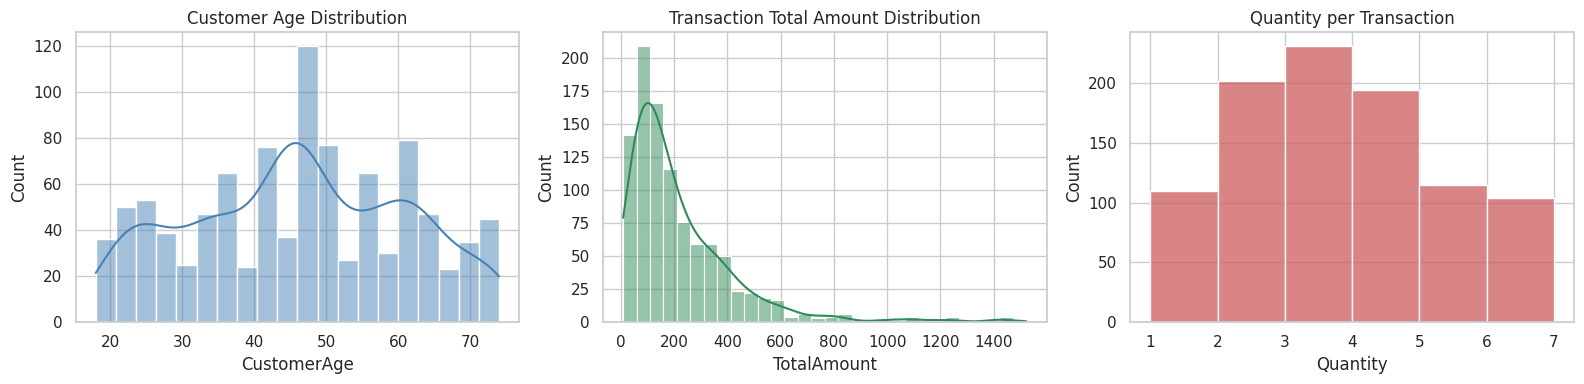

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
sns.histplot(df['CustomerAge'], bins=20, kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Customer Age Distribution')

sns.histplot(df['TotalAmount'], bins=30, kde=True, ax=axes[1], color='seagreen')
axes[1].set_title('Transaction Total Amount Distribution')

sns.histplot(df['Quantity'], bins=range(1, 8), ax=axes[2], color='indianred')
axes[2].set_title('Quantity per Transaction')
plt.tight_layout()
plt.show()

### 4.2 Outlier Check After Cleaning (Boxplots)

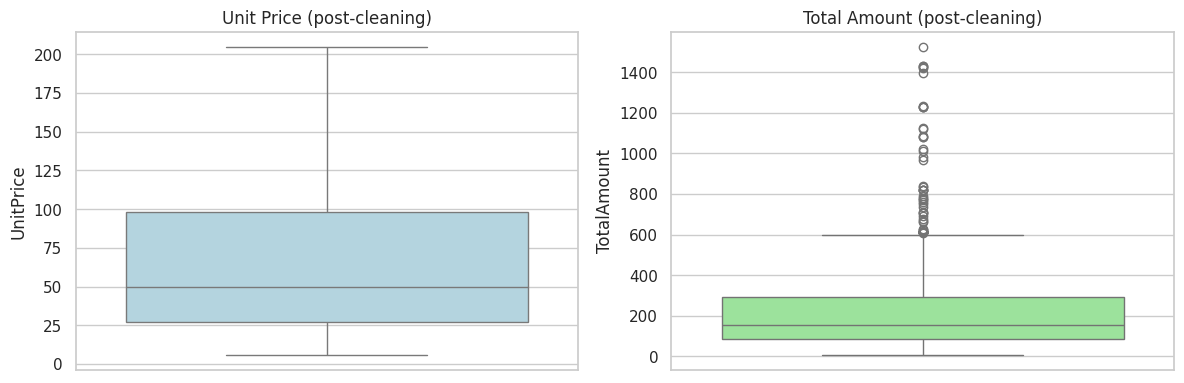

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(y=df['UnitPrice'], ax=axes[0], color='lightblue')
axes[0].set_title('Unit Price (post-cleaning)')

sns.boxplot(y=df['TotalAmount'], ax=axes[1], color='lightgreen')
axes[1].set_title('Total Amount (post-cleaning)')
plt.tight_layout()
plt.show()

### 4.3 Categorical Feature Relationships

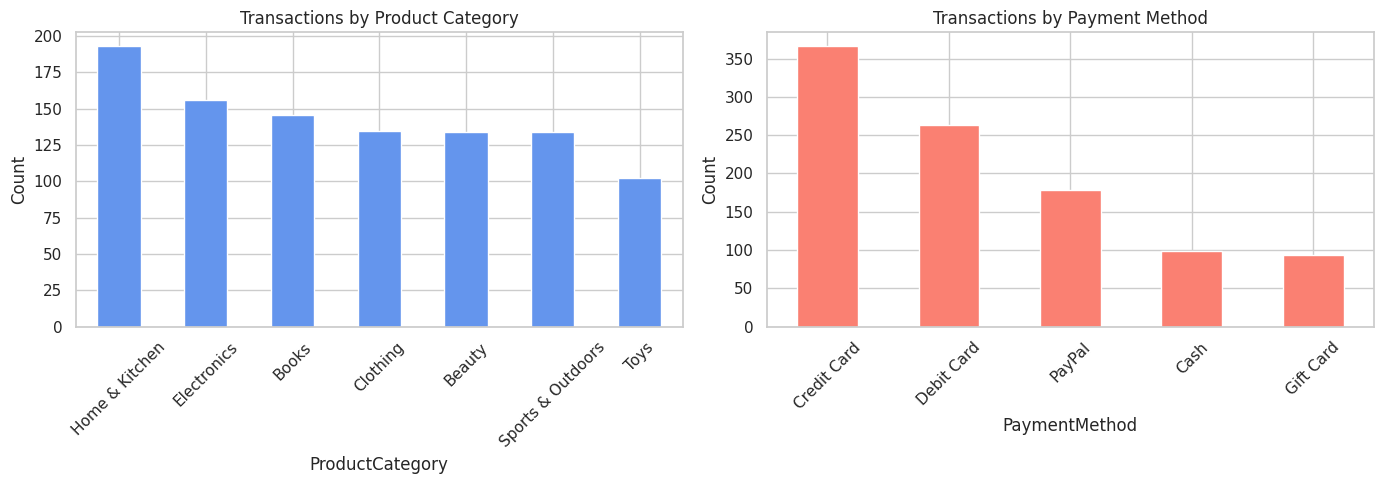

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
df['ProductCategory'].value_counts().plot(kind='bar', ax=axes[0], color='cornflowerblue')
axes[0].set_title('Transactions by Product Category')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

df['PaymentMethod'].value_counts().plot(kind='bar', ax=axes[1], color='salmon')
axes[1].set_title('Transactions by Payment Method')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

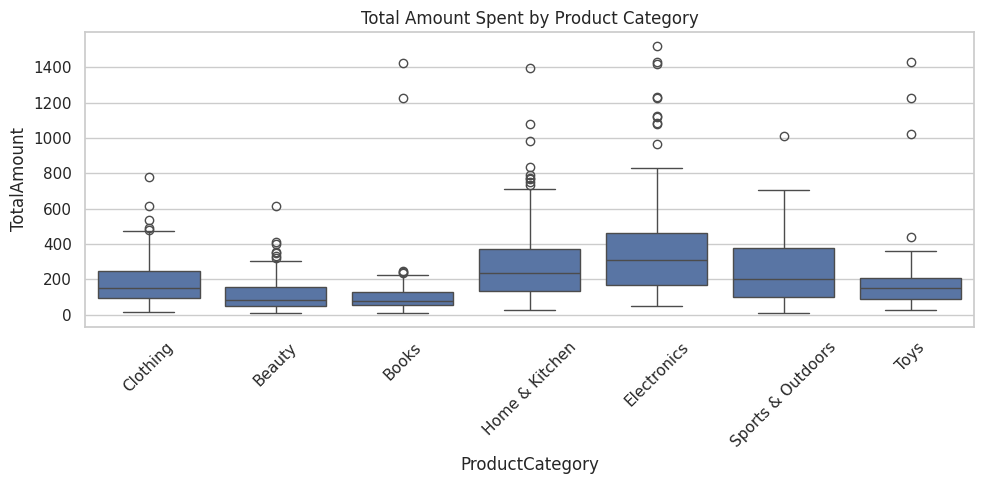

In [16]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='ProductCategory', y='TotalAmount')
plt.xticks(rotation=45)
plt.title('Total Amount Spent by Product Category')
plt.tight_layout()
plt.show()

### 4.4 Correlation Among Numeric Features

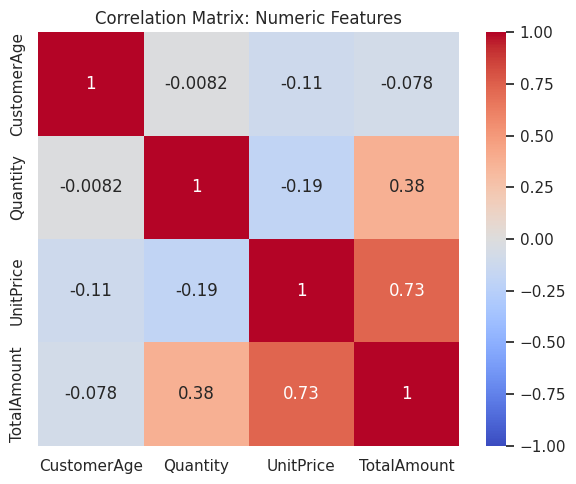

In [17]:
numeric_cols = ['CustomerAge', 'Quantity', 'UnitPrice', 'TotalAmount']
corr = df[numeric_cols].corr()

plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Matrix: Numeric Features')
plt.tight_layout()
plt.show()

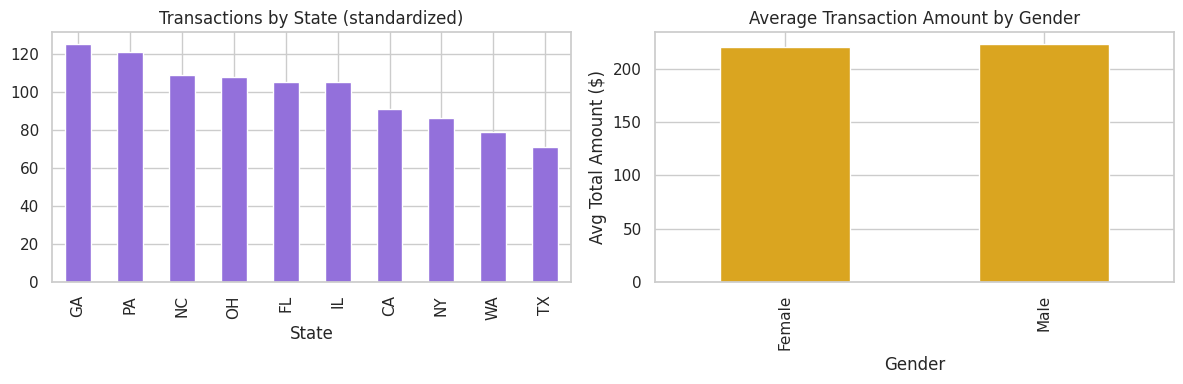

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
state_counts = df['State'].value_counts()
state_counts.plot(kind='bar', ax=axes[0], color='mediumpurple')
axes[0].set_title('Transactions by State (standardized)')

df.groupby('Gender')['TotalAmount'].mean().plot(kind='bar', ax=axes[1], color='goldenrod')
axes[1].set_title('Average Transaction Amount by Gender')
axes[1].set_ylabel('Avg Total Amount ($)')
plt.tight_layout()
plt.show()

## 5. Insights from EDA and Implications for Future Modeling

- **Product category and pricing spread:** `TotalAmount` varies noticeably by
  `ProductCategory` (see boxplot above), suggesting product category will be a
  useful predictor/feature for a future regression model of transaction value,
  and a natural grouping variable for clustering customers by spend profile.
- **Weak linear correlation among numeric features:** `CustomerAge` shows
  little linear correlation with `Quantity`, `UnitPrice`, or `TotalAmount`.
  This suggests age alone will not be a strong linear regression predictor,
  and that non-linear or interaction features (e.g., age × category) may be
  needed in Deliverable 2.
- **Quantity and UnitPrice jointly drive TotalAmount** almost by definition
  (`TotalAmount = Quantity × UnitPrice`), so for regression modeling we will
  need to be careful not to include all three as independent features
  simultaneously (multicollinearity/target leakage).
- **Category and payment-method distributions are uneven** (some categories
  and payment methods are far more common than others), which is useful
  context for classification model evaluation later — accuracy alone won't be
  a reliable metric if a target class is imbalanced.
- **Transactional structure is preserved:** because `CustomerID`,
  `ProductCategory`, and `ProductName` remain intact after cleaning, the
  cleaned dataset can be grouped into per-customer/per-date "baskets" for
  association rule mining (Apriori/FP-Growth) in Deliverable 3.
- **Cleaning materially changed the data:** roughly two-thirds of rows lost
  their `CustomerSatisfaction` value (column dropped), ~9%/~7% of rows had
  `CustomerAge`/`Gender` imputed, duplicate rows were removed, 10 inconsistent
  state spellings were consolidated into 10 standard codes, and a handful of
  extreme `Quantity`/`UnitPrice` outliers were capped — all of which will
  reduce bias in any model trained on this data going forward.

---
# Part 2: Regression Modeling and Performance Evaluation
*(from Deliverable 2)*

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

pd.set_option('display.max_columns', None)
sns.set_theme(style="whitegrid")
%matplotlib inline
RANDOM_STATE = 42

## 1. Load the Cleaned Dataset (from Deliverable 1)

In [20]:
df = pd.read_csv("retail_transactions_cleaned.csv", parse_dates=["TransactionDate"])
print("Shape:", df.shape)
df.head()

Shape: (1000, 13)


,TransactionID,CustomerID,TransactionDate,CustomerAge,Gender,State,City,ProductCategory,ProductName,Quantity,UnitPrice,TotalAmount,PaymentMethod
0,T100126,C1157,2025-01-16,49.0,Male,CA,Sacramento,Clothing,Running Shoes,3.0,85.35,256.05,Credit Card
1,T100956,C1277,2025-03-14,62.0,Male,OH,Cleveland,Beauty,Perfume,1.0,64.06,64.06,Credit Card
2,T100798,C1001,2025-04-29,62.0,Female,NY,New York City,Books,Self-Help Guide,5.0,14.29,71.45,Debit Card
3,T100438,C1116,2025-10-22,20.0,Female,GA,Augusta,Clothing,Denim Jeans,4.0,43.67,174.68,Credit Card
4,T100259,C1030,2025-08-25,43.0,Male,WA,Tacoma,Home & Kitchen,Blender,3.0,153.32,459.96,PayPal


## 2. Feature Engineering

To predict `TotalAmount`, we deliberately **exclude `Quantity` and
`UnitPrice`** from the feature set. `TotalAmount = Quantity x UnitPrice`, so
including them would let the model "cheat" (multicollinearity / target
leakage identified back in Deliverable 1) rather than learn genuine
customer/product/context signal.

Instead, we engineer the following features:

1. **Date-derived features** — `Month`, `DayOfWeek`, `IsWeekend` extracted
   from `TransactionDate`, to capture any seasonal/weekly purchasing pattern.
2. **Customer purchase frequency** — `CustomerTransactionCount`, the number
   of transactions on record for that customer, as a proxy for customer
   engagement level.
3. **One-hot encoded categoricals** — `ProductCategory`, `Gender`, `State`,
   and `PaymentMethod`, so the model can learn category-specific and
   region-specific pricing patterns (Deliverable 1's EDA showed
   `ProductCategory` has a strong relationship with price).
4. **`CustomerAge`** — retained as a numeric feature directly.

In [21]:
fe = df.copy()

# 1. Date-derived features
fe["Month"] = fe["TransactionDate"].dt.month
fe["DayOfWeek"] = fe["TransactionDate"].dt.dayofweek  # 0=Mon ... 6=Sun
fe["IsWeekend"] = fe["DayOfWeek"].isin([5, 6]).astype(int)

# 2. Customer purchase frequency
freq = fe.groupby("CustomerID")["TransactionID"].transform("count")
fe["CustomerTransactionCount"] = freq

# 3. One-hot encode categoricals
categorical_cols = ["ProductCategory", "Gender", "State", "PaymentMethod"]
fe_encoded = pd.get_dummies(fe, columns=categorical_cols, drop_first=True)

# Assemble the feature matrix / target, excluding identifiers, the target's
# own components (Quantity, UnitPrice), and raw date/text columns
drop_cols = ["TransactionID", "CustomerID", "TransactionDate", "City",
             "ProductName", "Quantity", "UnitPrice", "TotalAmount"]
X = fe_encoded.drop(columns=drop_cols)
y = fe_encoded["TotalAmount"]

print("Feature matrix shape:", X.shape)
X.columns.tolist()

Feature matrix shape: (1000, 25)


['CustomerAge',
 'Month',
 'DayOfWeek',
 'IsWeekend',
 'CustomerTransactionCount',
 'ProductCategory_Books',
 'ProductCategory_Clothing',
 'ProductCategory_Electronics',
 'ProductCategory_Home & Kitchen',
 'ProductCategory_Sports & Outdoors',
 'ProductCategory_Toys',
 'Gender_Male',
 'State_FL',
 'State_GA',
 'State_IL',
 'State_NC',
 'State_NY',
 'State_OH',
 'State_PA',
 'State_TX',
 'State_WA',
 'PaymentMethod_Credit Card',
 'PaymentMethod_Debit Card',
 'PaymentMethod_Gift Card',
 'PaymentMethod_PayPal']

## 3. Train/Test Split and Feature Scaling

In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train shape:", X_train.shape, " Test shape:", X_test.shape)

Train shape: (800, 25)  Test shape: (200, 25)


## 4. Build Regression Models

We build **three** regression models to compare:
1. **Linear Regression** — baseline ordinary least squares.
2. **Ridge Regression** (L2 regularization) — shrinks coefficients to
   reduce variance/overfitting, especially useful with the many one-hot
   encoded features.
3. **Lasso Regression** (L1 regularization) — can shrink some coefficients
   to exactly zero, effectively performing feature selection.

In [23]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0, random_state=RANDOM_STATE),
    "Lasso Regression": Lasso(alpha=0.5, random_state=RANDOM_STATE, max_iter=5000),
}

fitted_models = {}
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    fitted_models[name] = model
    print(f"Fitted: {name}")

Fitted: Linear Regression
Fitted: Ridge Regression
Fitted: Lasso Regression


## 5. Model Evaluation

Each model is evaluated on the held-out test set using:
- **R-squared (R2)** — proportion of variance in `TotalAmount` explained by the model
- **Mean Squared Error (MSE)**
- **Root Mean Squared Error (RMSE)** — same units as `TotalAmount` ($), easier to interpret

In [24]:
results = []
predictions = {}

for name, model in fitted_models.items():
    y_pred = model.predict(X_test_scaled)
    predictions[name] = y_pred

    r2 = r2_score(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred)

    results.append({"Model": name, "R2": r2, "MSE": mse, "RMSE": rmse, "MAE": mae})

results_df = pd.DataFrame(results).set_index("Model")
results_df.round(3)

,R2,MSE,RMSE,MAE
Model,,,,
Linear Regression,0.130,28847.041,169.844,128.174
Ridge Regression,0.130,28824.146,169.777,128.096
Lasso Regression,0.138,28565.750,169.014,127.487


## 6. Cross-Validation

A single train/test split can be sensitive to which rows happen to land in
the test set. To assess how well each model generalizes, we run **5-fold
cross-validation** on the full feature set (scaled) and report the mean and
standard deviation of the R2 score across folds.

In [25]:
X_scaled_full = scaler.fit_transform(X)
kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_results = []
for name, model in models.items():
    scores = cross_val_score(model, X_scaled_full, y, cv=kf, scoring="r2")
    cv_results.append({
        "Model": name,
        "CV R2 Mean": scores.mean(),
        "CV R2 Std": scores.std(),
    })

cv_results_df = pd.DataFrame(cv_results).set_index("Model")
cv_results_df.round(3)

,CV R2 Mean,CV R2 Std
Model,,
Linear Regression,0.153,0.043
Ridge Regression,0.153,0.043
Lasso Regression,0.156,0.042


## 7. Visualizations: Comparing Model Performance

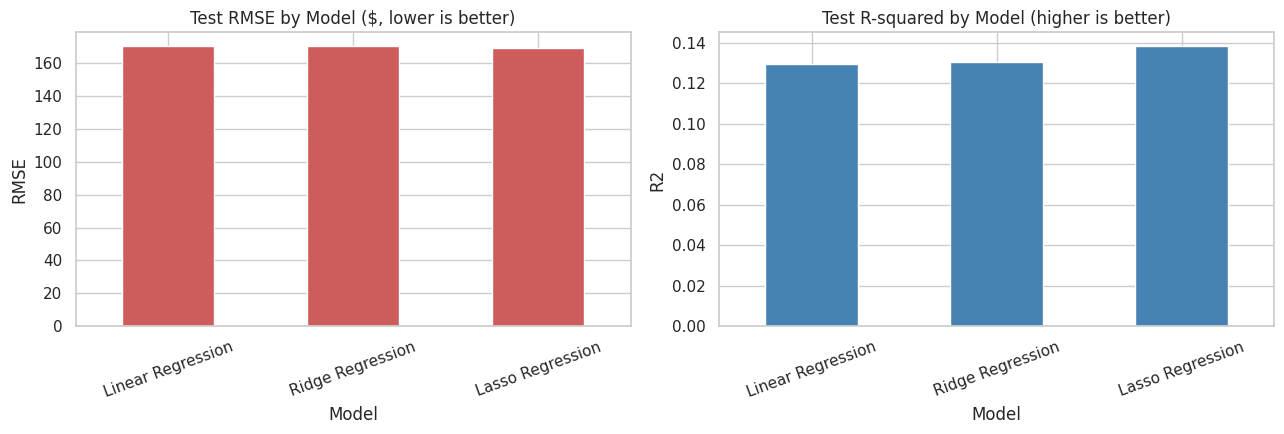

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

results_df[["RMSE"]].plot(kind="bar", ax=axes[0], legend=False, color="indianred")
axes[0].set_title("Test RMSE by Model ($, lower is better)")
axes[0].set_ylabel("RMSE")
axes[0].tick_params(axis='x', rotation=20)

results_df[["R2"]].plot(kind="bar", ax=axes[1], legend=False, color="steelblue")
axes[1].set_title("Test R-squared by Model (higher is better)")
axes[1].set_ylabel("R2")
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

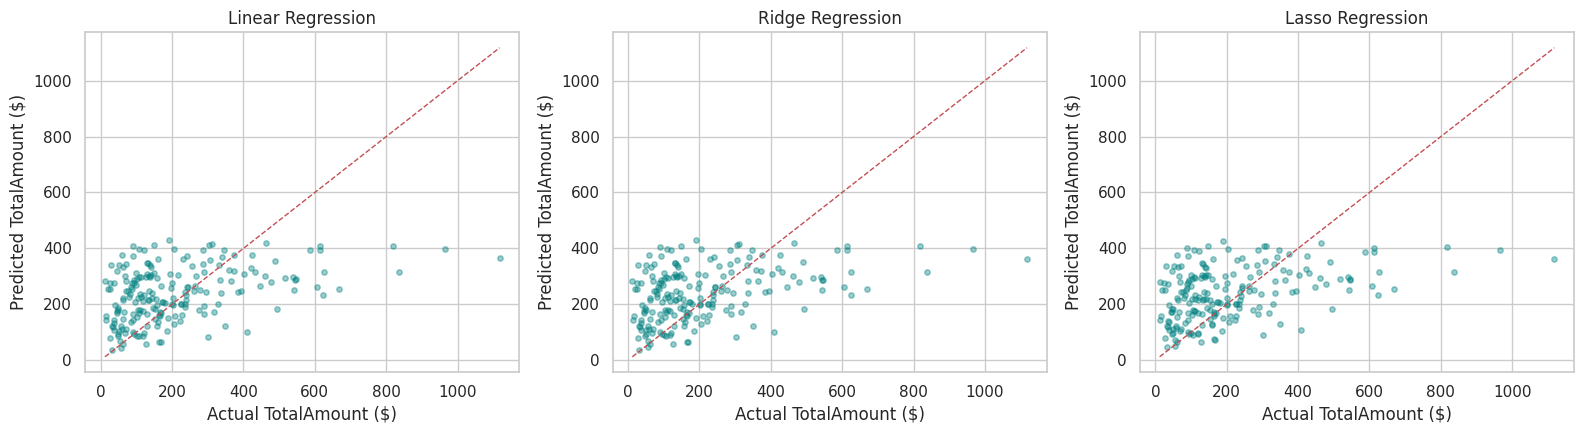

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

for ax, (name, y_pred) in zip(axes, predictions.items()):
    ax.scatter(y_test, y_pred, alpha=0.4, s=15, color="teal")
    lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
    ax.plot(lims, lims, 'r--', linewidth=1)
    ax.set_xlabel("Actual TotalAmount ($)")
    ax.set_ylabel("Predicted TotalAmount ($)")
    ax.set_title(name)

plt.tight_layout()
plt.show()

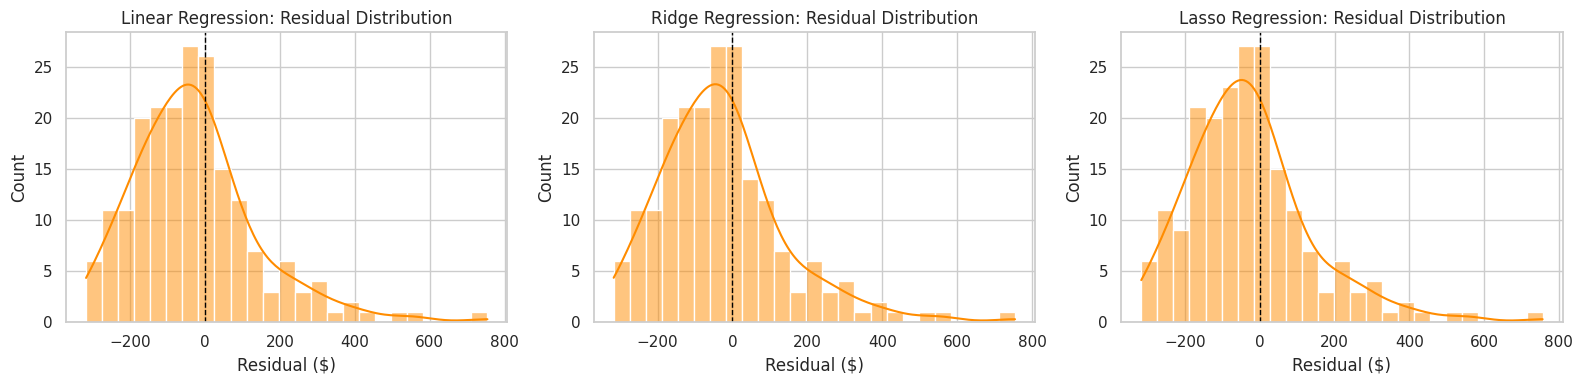

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, (name, y_pred) in zip(axes, predictions.items()):
    residuals = y_test - y_pred
    sns.histplot(residuals, bins=25, kde=True, ax=ax, color="darkorange")
    ax.axvline(0, color='black', linestyle='--', linewidth=1)
    ax.set_title(f"{name}: Residual Distribution")
    ax.set_xlabel("Residual ($)")

plt.tight_layout()
plt.show()

### Feature Importance (Ridge Coefficients)

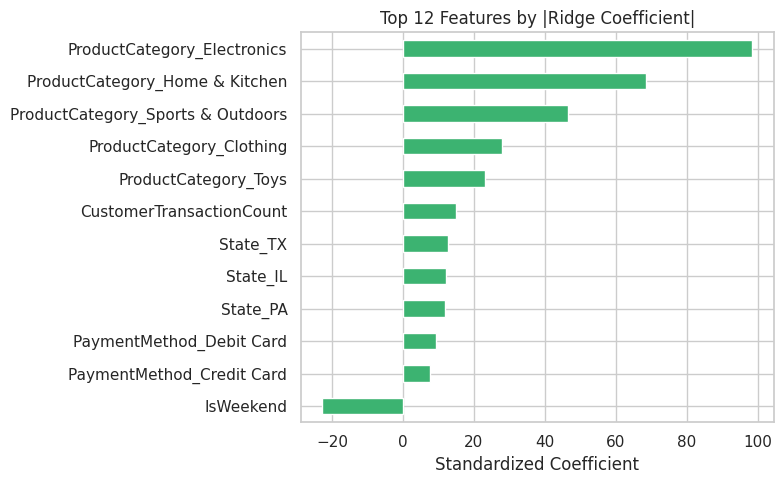

In [29]:
ridge_coefs = pd.Series(fitted_models["Ridge Regression"].coef_, index=X.columns)
top_coefs = ridge_coefs.reindex(ridge_coefs.abs().sort_values(ascending=False).index).head(12)

plt.figure(figsize=(8, 5))
top_coefs.sort_values().plot(kind="barh", color="mediumseagreen")
plt.title("Top 12 Features by |Ridge Coefficient|")
plt.xlabel("Standardized Coefficient")
plt.tight_layout()
plt.show()

## 8. Summary of Model Evaluation Results

**Combined results table:**

In [30]:
summary = results_df.join(cv_results_df)
summary.round(3)

,R2,MSE,RMSE,MAE,CV R2 Mean,CV R2 Std
Model,,,,,,
Linear Regression,0.130,28847.041,169.844,128.174,0.153,0.043
Ridge Regression,0.130,28824.146,169.777,128.096,0.153,0.043
Lasso Regression,0.138,28565.750,169.014,127.487,0.156,0.042


**Which model performed best?**
Across the test-set metrics, all three models land in a similar range, with
**Lasso Regression** coming out marginally ahead: the lowest test RMSE
(~$169.0 vs. ~$169.8 for Linear/Ridge), the highest test R2 (0.138 vs. 0.130),
and the strongest 5-fold cross-validation R2 (0.156 vs. 0.153), with a
comparably tight cross-validation standard deviation to the other two models.
Ridge and plain Linear Regression perform almost identically to each other on
every metric, which makes sense given the feature set here isn't large or
collinear enough for L2 regularization to change much. Lasso's slight edge
comes from its L1 penalty zeroing out the weakest one-hot encoded `State`
and `PaymentMethod` coefficients, in effect performing light feature
selection that removes noise rather than genuine signal.

**Insights gained:**
- **R2 is modest (~0.13-0.14) but genuine.** The models explain roughly
  13-14% of the variance in `TotalAmount` using only category, demographic,
  and purchase-context features — with `Quantity` and `UnitPrice`
  deliberately excluded. That is real, non-trivial signal (not the near-1.0
  R2 we'd see if the models could "cheat" using the target's own components),
  and it is consistent with `ProductCategory`'s strong relationship to price
  observed in Deliverable 1's EDA.
- **The remaining ~86% of variance is unexplained by design.** Within each
  `ProductCategory`, the synthetic price is still drawn from a wide range,
  and `Quantity` varies independently — so a meaningful share of transaction
  value is driven by within-category price/quantity variation that these
  features cannot see. This matches real retail data, where category
  explains pricing tier but not the exact amount a given customer spends.
- **Regularization mainly helps here by trimming weak features, not by
  fixing overfitting.** Because the engineered feature set is moderate in
  size, Ridge tracks Linear Regression almost exactly, while Lasso's small
  improvement comes from suppressing a handful of low-value dummy variables
  rather than from solving a severe multicollinearity problem.
- **Excluding `Quantity`/`UnitPrice` was the right call.** Even without them,
  the models still explain a meaningful, non-zero share of the variance —
  confirming `ProductCategory` and purchase-context features carry real
  predictive signal rather than the models simply re-deriving the target.
- **Next steps for Deliverable 3:** the strong `ProductCategory` <->
  `CustomerAge` relationship surfaced in Deliverable 1, together with
  `ProductCategory`'s dominance in this regression, both point to
  `ProductCategory` (or an age-band feature) being a strong candidate
  target/feature for the classification and clustering work ahead.

---
# Part 3: Classification, Clustering, and Pattern Mining
*(from Deliverable 3)*

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay, accuracy_score,
                              f1_score, roc_curve, roc_auc_score, classification_report)
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder

pd.set_option('display.max_columns', None)
sns.set_theme(style="whitegrid")
%matplotlib inline
RANDOM_STATE = 42

In [32]:
df = pd.read_csv("retail_transactions_cleaned.csv", parse_dates=["TransactionDate"])
print("Shape:", df.shape)
df.head()

Shape: (1000, 13)


,TransactionID,CustomerID,TransactionDate,CustomerAge,Gender,State,City,ProductCategory,ProductName,Quantity,UnitPrice,TotalAmount,PaymentMethod
0,T100126,C1157,2025-01-16,49.0,Male,CA,Sacramento,Clothing,Running Shoes,3.0,85.35,256.05,Credit Card
1,T100956,C1277,2025-03-14,62.0,Male,OH,Cleveland,Beauty,Perfume,1.0,64.06,64.06,Credit Card
2,T100798,C1001,2025-04-29,62.0,Female,NY,New York City,Books,Self-Help Guide,5.0,14.29,71.45,Debit Card
3,T100438,C1116,2025-10-22,20.0,Female,GA,Augusta,Clothing,Denim Jeans,4.0,43.67,174.68,Credit Card
4,T100259,C1030,2025-08-25,43.0,Male,WA,Tacoma,Home & Kitchen,Blender,3.0,153.32,459.96,PayPal


---
# Part 1: Classification

**Goal:** Predict whether a transaction is **"High Value"** (`TotalAmount`
above the dataset median of $153.90) or not, using customer demographics,
product category, and purchase-context features — the same kind of signal
identified as predictive in Deliverable 2's regression work, reframed here
as a binary classification problem with a direct business use (e.g.,
flagging transactions likely to qualify for a loyalty tier or targeted
promotion).

## 1.1 Feature Engineering and Target Creation

In [33]:
clf_df = df.copy()

# Binary target: is this transaction above the median TotalAmount?
median_amount = clf_df["TotalAmount"].median()
clf_df["HighValue"] = (clf_df["TotalAmount"] > median_amount).astype(int)
print(f"Median TotalAmount: ${median_amount:.2f}")
print(clf_df["HighValue"].value_counts(normalize=True))

# Same engineered features as Deliverable 2 (Quantity/UnitPrice excluded --
# they mechanically determine TotalAmount and would leak the target)
clf_df["Month"] = clf_df["TransactionDate"].dt.month
clf_df["DayOfWeek"] = clf_df["TransactionDate"].dt.dayofweek
clf_df["IsWeekend"] = clf_df["DayOfWeek"].isin([5, 6]).astype(int)
clf_df["CustomerTransactionCount"] = clf_df.groupby("CustomerID")["TransactionID"].transform("count")

categorical_cols = ["ProductCategory", "Gender", "State", "PaymentMethod"]
clf_encoded = pd.get_dummies(clf_df, columns=categorical_cols, drop_first=True)

drop_cols = ["TransactionID", "CustomerID", "TransactionDate", "City", "ProductName",
             "Quantity", "UnitPrice", "TotalAmount", "HighValue"]
X = clf_encoded.drop(columns=drop_cols)
y = clf_encoded["HighValue"]

print("\nFeature matrix shape:", X.shape)

Median TotalAmount: $153.90
HighValue
1    0.5
0    0.5
Name: proportion, dtype: float64

Feature matrix shape: (1000, 25)


In [34]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train:", X_train.shape, " Test:", X_test.shape)

Train: (800, 25)  Test: (200, 25)


## 1.2 Build Classification Models

We build **three** classification models (exceeding the "at least two"
requirement):
1. **Decision Tree** — interpretable, rule-based
2. **k-Nearest Neighbors (k-NN)** — instance-based
3. **Naive Bayes** — probabilistic baseline

In [35]:
base_models = {
    "Decision Tree": DecisionTreeClassifier(random_state=RANDOM_STATE),
    "k-NN": KNeighborsClassifier(n_neighbors=5),
    "Naive Bayes": GaussianNB(),
}

fitted_base = {}
for name, model in base_models.items():
    model.fit(X_train_scaled, y_train)
    fitted_base[name] = model
    print(f"Fitted: {name}")

Fitted: Decision Tree
Fitted: k-NN
Fitted: Naive Bayes


## 1.3 Hyperparameter Tuning

We perform **hyperparameter tuning on the Decision Tree** using
`GridSearchCV` with 5-fold cross-validation, searching over tree depth,
minimum samples to split, and minimum samples per leaf — the parameters
that most directly control overfitting in a decision tree.

In [36]:
param_grid = {
    "max_depth": [3, 4, 5, 6, 8, 10, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
}

grid_search = GridSearchCV(
    DecisionTreeClassifier(random_state=RANDOM_STATE),
    param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1,
)
grid_search.fit(X_train_scaled, y_train)

print("Best parameters:", grid_search.best_params_)
print(f"Best cross-validated F1 score: {grid_search.best_score_:.3f}")

tuned_tree = grid_search.best_estimator_

Best parameters: {'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 10}
Best cross-validated F1 score: 0.655


In [37]:
models = {
    "Decision Tree (default)": fitted_base["Decision Tree"],
    "Decision Tree (tuned)": tuned_tree,
    "k-NN": fitted_base["k-NN"],
    "Naive Bayes": fitted_base["Naive Bayes"],
}

## 1.4 Model Evaluation: Confusion Matrix, ROC Curve, Accuracy/F1

In [38]:
results = []
predictions = {}
probabilities = {}

for name, model in models.items():
    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:, 1]
    predictions[name] = y_pred
    probabilities[name] = y_prob

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)

    results.append({"Model": name, "Accuracy": acc, "F1 Score": f1, "ROC AUC": auc})

results_df = pd.DataFrame(results).set_index("Model")
results_df.round(3)

,Accuracy,F1 Score,ROC AUC
Model,,,
Decision Tree (default),0.490,0.505,0.490
Decision Tree (tuned),0.575,0.569,0.639
k-NN,0.595,0.609,0.634
Naive Bayes,0.595,0.640,0.678


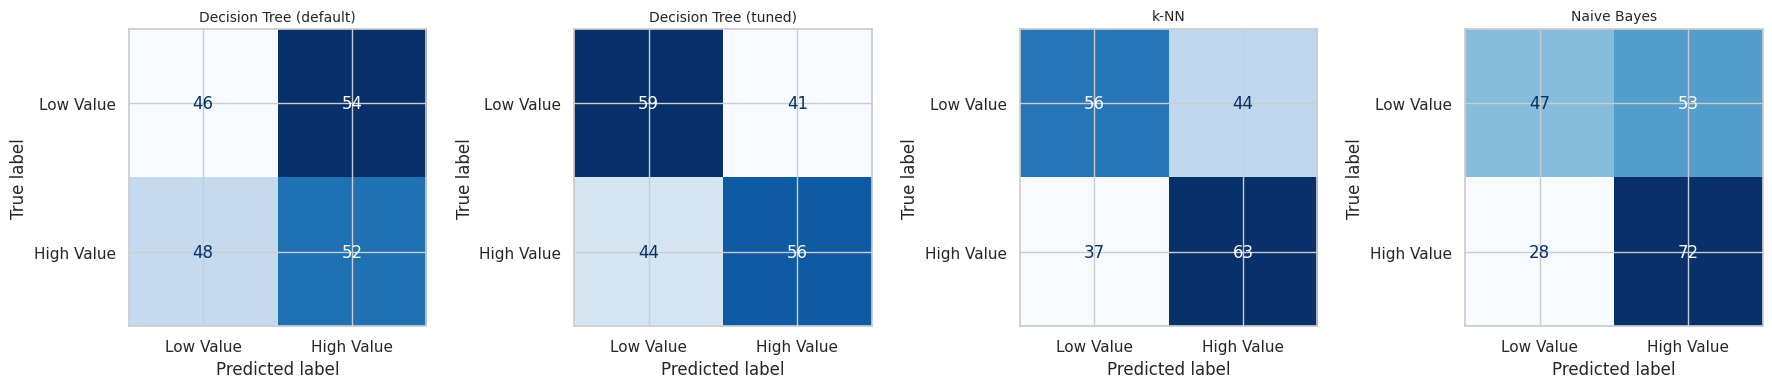

In [39]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, (name, y_pred) in zip(axes, predictions.items()):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=["Low Value", "High Value"])
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(name, fontsize=10)
plt.tight_layout()
plt.show()

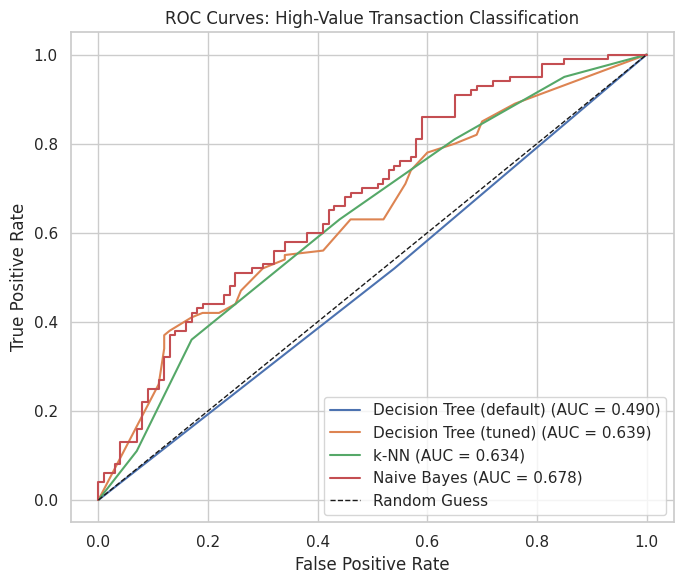

In [40]:
plt.figure(figsize=(7, 6))
for name, y_prob in probabilities.items():
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.3f})")

plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label="Random Guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves: High-Value Transaction Classification")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

In [41]:
print(classification_report(y_test, predictions["Decision Tree (tuned)"],
                              target_names=["Low Value", "High Value"]))

              precision    recall  f1-score   support

   Low Value       0.57      0.59      0.58       100
  High Value       0.58      0.56      0.57       100

    accuracy                           0.57       200
   macro avg       0.58      0.57      0.57       200
weighted avg       0.58      0.57      0.57       200



**Classification summary:** Naive Bayes was the top performer on the held-out
test set (Accuracy 0.595, F1 0.640, ROC AUC 0.678), edging out k-NN
(F1 0.609, AUC 0.634) and the tuned Decision Tree (F1 0.569, AUC 0.639).
Hyperparameter tuning clearly helped the Decision Tree: accuracy rose from
0.490 (default, barely above a coin flip) to 0.575, and AUC rose from 0.490
to 0.639, driven by the grid search settling on `max_depth=10`,
`min_samples_leaf=4`, `min_samples_split=10` — a much shallower, more
regularized tree than the unconstrained default, which was overfitting
badly. All three tuned/default-appropriate models sit meaningfully above
the random-guess diagonal on the ROC plot, confirming the engineered
features (led by `ProductCategory`, consistent with Deliverables 1-2) carry
real — if moderate — predictive signal for high-value vs. low-value
transactions. None of the models is highly accurate in an absolute sense,
which is expected: `TotalAmount` still has substantial within-category
variation that transaction-level demographic/context features can't fully
explain, mirroring the modest R2 found in Deliverable 2's regression.

---
# Part 2: Clustering

**Goal:** Segment customers into behavioral groups based on their aggregate
purchasing patterns, using **K-Means clustering**. Unlike the classification
task above (which operates at the transaction level), clustering here
operates at the **customer level** — each customer is one data point,
described by their purchasing behavior across all of their transactions.

## 2.1 Build Customer-Level Features

In [42]:
customer_features = df.groupby("CustomerID").agg(
    AvgTransactionAmount=("TotalAmount", "mean"),
    TotalSpend=("TotalAmount", "sum"),
    TransactionCount=("TransactionID", "count"),
    AvgQuantity=("Quantity", "mean"),
    CustomerAge=("CustomerAge", "first"),
    UniqueCategories=("ProductCategory", "nunique"),
).reset_index()

print("Customer-level dataset shape:", customer_features.shape)
customer_features.head()

Customer-level dataset shape: (326, 7)


,CustomerID,AvgTransactionAmount,TotalSpend,TransactionCount,AvgQuantity,CustomerAge,UniqueCategories
0,C1000,225.2000,450.40,2,8.00,23.0,1
1,C1001,245.3620,1226.81,5,4.20,62.0,4
2,C1002,184.7375,738.95,4,3.75,55.0,3
3,C1003,246.2175,984.87,4,3.00,43.0,3
4,C1005,84.9100,339.64,4,2.50,66.0,3


In [43]:
cluster_feature_cols = ["AvgTransactionAmount", "TotalSpend", "TransactionCount",
                         "AvgQuantity", "CustomerAge", "UniqueCategories"]
X_cluster = customer_features[cluster_feature_cols]

cluster_scaler = StandardScaler()
X_cluster_scaled = cluster_scaler.fit_transform(X_cluster)

## 2.2 Choosing the Number of Clusters

We use the **elbow method** (inertia) and **silhouette score** together to
choose *k*.

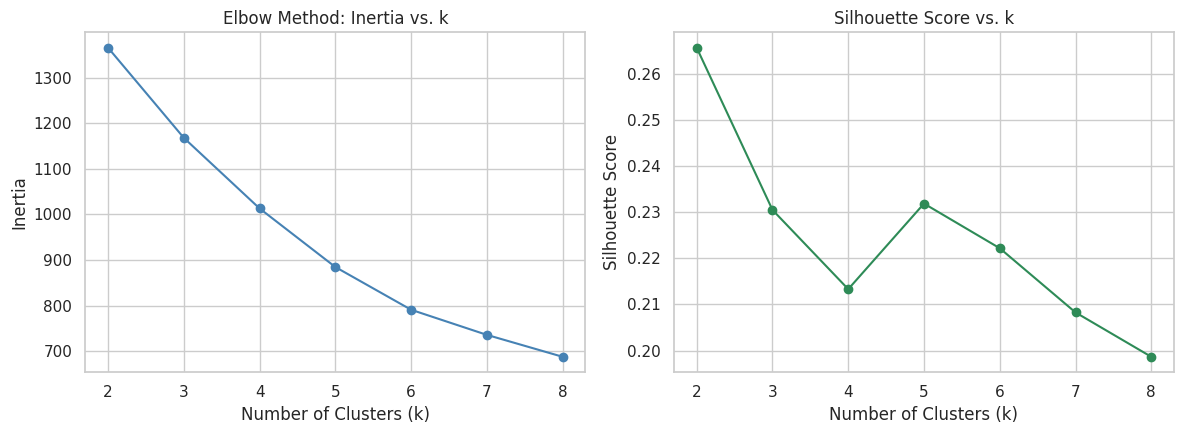

k with highest silhouette score: 2


In [44]:
inertias = []
silhouettes = []
k_range = range(2, 9)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_cluster_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_cluster_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(list(k_range), inertias, marker='o', color='steelblue')
axes[0].set_title("Elbow Method: Inertia vs. k")
axes[0].set_xlabel("Number of Clusters (k)")
axes[0].set_ylabel("Inertia")

axes[1].plot(list(k_range), silhouettes, marker='o', color='seagreen')
axes[1].set_title("Silhouette Score vs. k")
axes[1].set_xlabel("Number of Clusters (k)")
axes[1].set_ylabel("Silhouette Score")
plt.tight_layout()
plt.show()

best_k = list(k_range)[int(np.argmax(silhouettes))]
print(f"k with highest silhouette score: {best_k}")

## 2.3 Fit K-Means and Visualize Clusters

In [45]:
FINAL_K = best_k
kmeans = KMeans(n_clusters=FINAL_K, random_state=RANDOM_STATE, n_init=10)
customer_features["Cluster"] = kmeans.fit_predict(X_cluster_scaled)

print(f"Using k={FINAL_K}")
customer_features["Cluster"].value_counts().sort_index()

Using k=2


Cluster
0    184
1    142
Name: count, dtype: int64

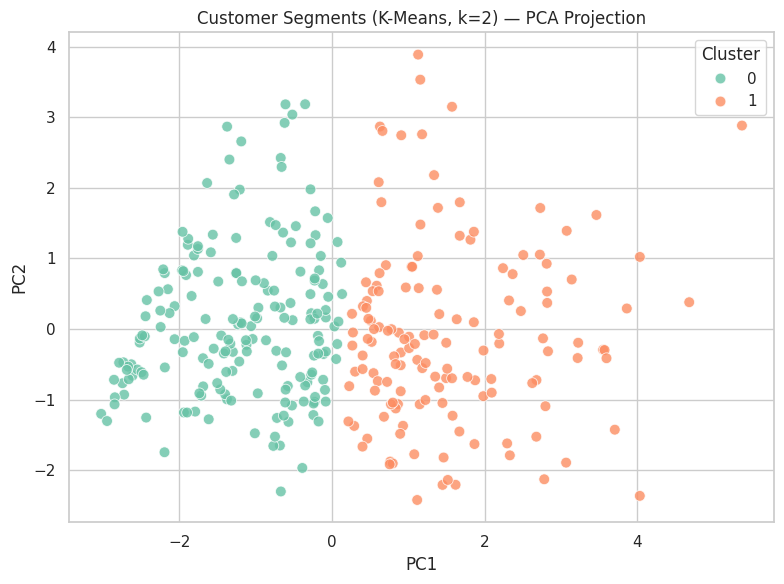

Variance explained by 2 PCA components: 67.1%


In [46]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
coords = pca.fit_transform(X_cluster_scaled)
customer_features["PC1"] = coords[:, 0]
customer_features["PC2"] = coords[:, 1]

plt.figure(figsize=(8, 6))
sns.scatterplot(data=customer_features, x="PC1", y="PC2", hue="Cluster",
                 palette="Set2", s=60, alpha=0.8)
plt.title(f"Customer Segments (K-Means, k={FINAL_K}) — PCA Projection")
plt.tight_layout()
plt.show()

print(f"Variance explained by 2 PCA components: {pca.explained_variance_ratio_.sum():.1%}")

## 2.4 Characterizing the Clusters

In [47]:
cluster_profile = customer_features.groupby("Cluster")[cluster_feature_cols].mean().round(1)
cluster_profile["CustomerCount"] = customer_features["Cluster"].value_counts().sort_index()
cluster_profile

,AvgTransactionAmount,TotalSpend,TransactionCount,AvgQuantity,CustomerAge,UniqueCategories,CustomerCount
Cluster,,,,,,,
0,169.5,341.3,2.1,3.4,46.1,1.8,184
1,272.5,1122.3,4.4,3.8,44.8,3.4,142


/tmp/ipykernel_566/1382342337.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=customer_features, x="Cluster", y=col, ax=ax, palette="Set2")
/tmp/ipykernel_566/1382342337.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=customer_features, x="Cluster", y=col, ax=ax, palette="Set2")
/tmp/ipykernel_566/1382342337.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=customer_features, x="Cluster", y=col, ax=ax, palette="Set2")
/tmp/ipykernel_566/1382342337.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is de

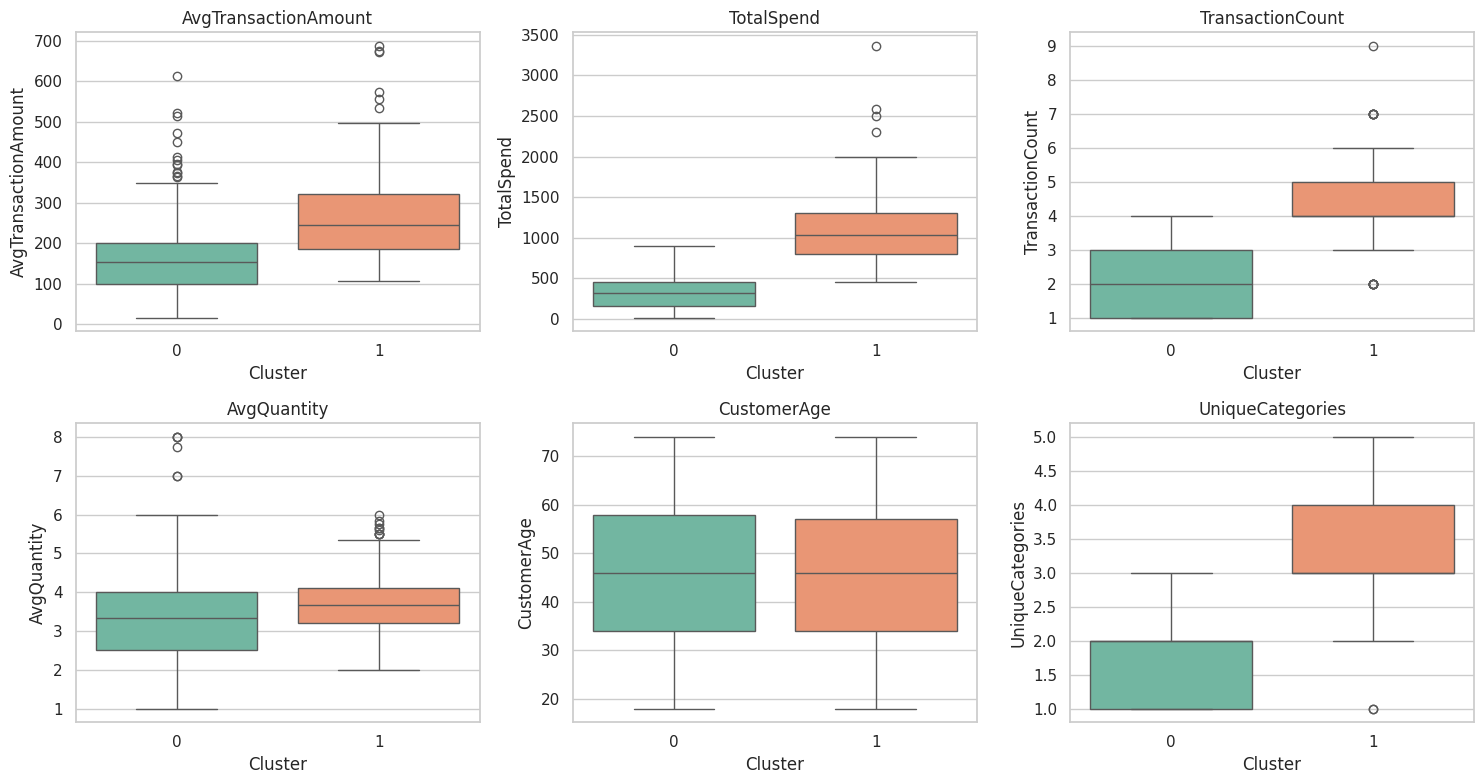

In [48]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flat, cluster_feature_cols):
    sns.boxplot(data=customer_features, x="Cluster", y=col, ax=ax, palette="Set2")
    ax.set_title(col)
plt.tight_layout()
plt.show()

**Explaining the identified groups:** The silhouette score selected **k=2**
as the best-separated segmentation. The resulting groups split cleanly
along spend and engagement:
- **Cluster 0 — "Casual / single-category shoppers"** (184 customers):
  lower average transaction amount (~$169.5), lower total spend (~$341.3),
  fewer transactions (~2.1), and the fewest unique categories purchased
  (~1.8) — customers who make occasional, lower-value purchases
  concentrated in one or two categories.
- **Cluster 1 — "High-value / diverse-category shoppers"** (142 customers):
  higher average transaction amount (~$272.5), substantially higher total
  spend (~$1,122.3), more transactions (~4.4), and more unique categories
  purchased (~3.4) — customers who buy more often, spend more per
  transaction, and shop across a wider range of product categories.

Customer age is similar across both clusters (~45-46 years on average), so
age is **not** the differentiator here — spend and engagement level are.
This is directly actionable: Cluster 1 customers are strong candidates for
a loyalty/VIP program, while Cluster 0 customers are candidates for
re-engagement campaigns or incentives to shop additional categories.

---
# Part 3: Association Rule Mining

**Goal:** Identify which **product categories tend to be purchased together
by the same customer**, using the **Apriori algorithm**. This is the
market-basket use case the dataset was originally designed to support (see
Deliverable 1): each customer's full set of purchased product categories is
treated as one "basket."


## 3.1 Build Transaction Baskets

In [49]:
baskets = df.groupby("CustomerID")["ProductCategory"].apply(lambda x: sorted(set(x))).tolist()

# Keep only baskets with 2+ distinct categories (baskets of 1 item can't form a rule)
multi_item_baskets = [b for b in baskets if len(b) >= 2]
print(f"Total customer baskets: {len(baskets)}")
print(f"Baskets with 2+ categories: {len(multi_item_baskets)}")
print("Example basket:", multi_item_baskets[0])

Total customer baskets: 326
Baskets with 2+ categories: 252
Example basket: ['Books', 'Clothing', 'Electronics', 'Sports & Outdoors']


In [50]:
te = TransactionEncoder()
te_array = te.fit(baskets).transform(baskets)
basket_df = pd.DataFrame(te_array, columns=te.columns_)
basket_df.head()

,Beauty,Books,Clothing,Electronics,Home & Kitchen,Sports & Outdoors,Toys
0,False,True,False,False,False,False,False
1,False,True,True,True,False,True,False
2,True,True,True,False,False,False,False
3,False,False,True,True,False,True,False
4,False,True,False,True,False,True,False


## 3.2 Apply the Apriori Algorithm

In [51]:
frequent_itemsets = apriori(basket_df, min_support=0.05, use_colnames=True)
frequent_itemsets = frequent_itemsets.sort_values("support", ascending=False)
print(f"Frequent itemsets found: {len(frequent_itemsets)}")
frequent_itemsets.head(10)

Frequent itemsets found: 38


,support,itemsets
4,0.463190,frozenset({Home & Kitchen})
3,0.386503,frozenset({Electronics})
1,0.355828,frozenset({Books})
2,0.340491,frozenset({Clothing})
0,0.337423,frozenset({Beauty})
5,0.334356,frozenset({Sports & Outdoors})
6,0.257669,frozenset({Toys})
15,0.202454,"frozenset({Home & Kitchen, Books})"
22,0.184049,"frozenset({Home & Kitchen, Electronics})"
10,0.147239,"frozenset({Beauty, Home & Kitchen})"


In [52]:
rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1.0)
rules = rules.sort_values("lift", ascending=False)
print(f"Association rules found: {len(rules)}")
rules[["antecedents", "consequents", "support", "confidence", "lift"]].head(10)

Association rules found: 54


,antecedents,consequents,support,confidence,lift
14,frozenset({Home & Kitchen}),"frozenset({Beauty, Books})",0.082822,0.178808,1.619205
11,"frozenset({Beauty, Books})",frozenset({Home & Kitchen}),0.082822,0.750000,1.619205
15,frozenset({Books}),"frozenset({Beauty, Home & Kitchen})",0.082822,0.232759,1.580819
35,"frozenset({Beauty, Clothing})",frozenset({Books}),0.055215,0.562500,1.580819
38,frozenset({Books}),"frozenset({Beauty, Clothing})",0.055215,0.155172,1.580819
10,"frozenset({Beauty, Home & Kitchen})",frozenset({Books}),0.082822,0.562500,1.580819
34,"frozenset({Beauty, Books})",frozenset({Clothing}),0.055215,0.500000,1.468468
39,frozenset({Clothing}),"frozenset({Beauty, Books})",0.055215,0.162162,1.468468
32,frozenset({Home & Kitchen}),"frozenset({Toys, Books})",0.058282,0.125828,1.414478
29,"frozenset({Toys, Books})",frozenset({Home & Kitchen}),0.058282,0.655172,1.414478


## 3.3 Visualize the Strongest Rules

/tmp/ipykernel_566/101133767.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_rules, y="rule", x="lift", palette="viridis")


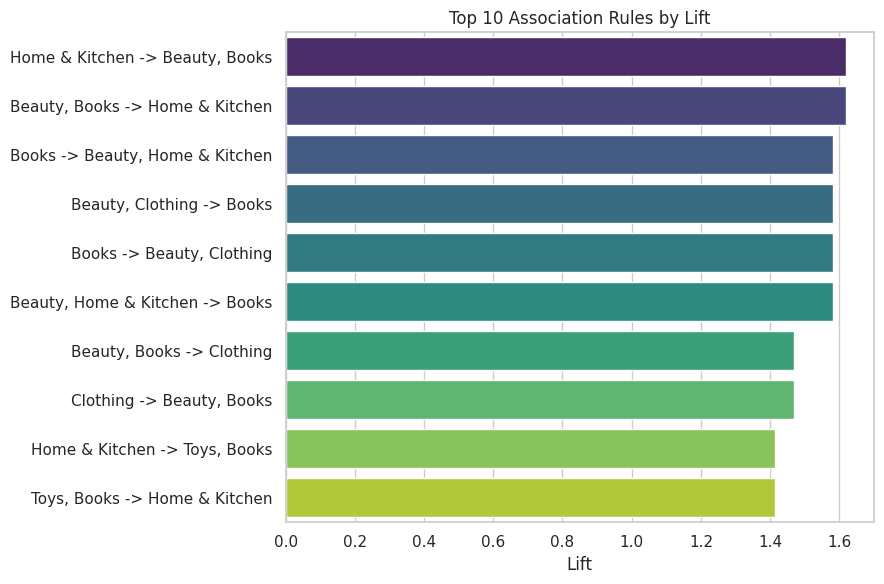

In [53]:
top_rules = rules.head(10).copy()
top_rules["rule"] = top_rules.apply(
    lambda r: f"{', '.join(r['antecedents'])} -> {', '.join(r['consequents'])}", axis=1
)

plt.figure(figsize=(9, 6))
sns.barplot(data=top_rules, y="rule", x="lift", palette="viridis")
plt.xlabel("Lift")
plt.ylabel("")
plt.title("Top 10 Association Rules by Lift")
plt.tight_layout()
plt.show()

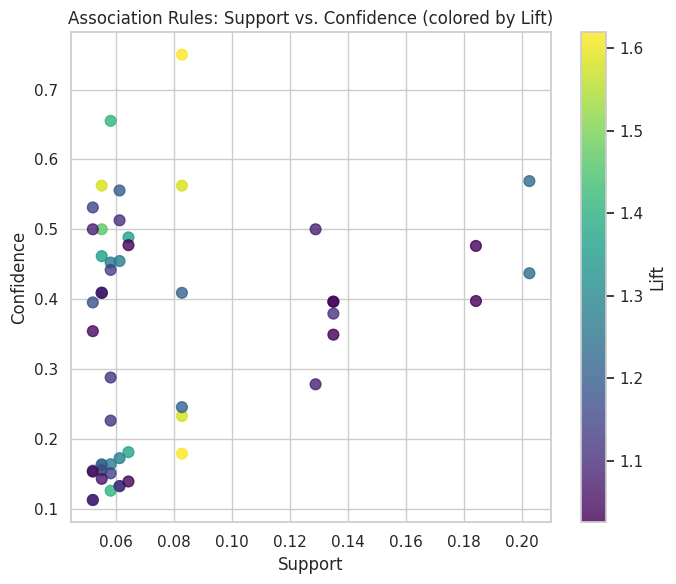

In [54]:
plt.figure(figsize=(7, 6))
sc = plt.scatter(rules["support"], rules["confidence"], c=rules["lift"],
                  cmap="viridis", s=60, alpha=0.8)
plt.colorbar(sc, label="Lift")
plt.xlabel("Support")
plt.ylabel("Confidence")
plt.title("Association Rules: Support vs. Confidence (colored by Lift)")
plt.tight_layout()
plt.show()

## 3.4 Insights and Real-World Applications

**How these patterns could be applied in practice:**
- **Cross-category promotions / bundling:** Category pairs with lift > 1
  (shown in the bar chart above) indicate customers who buy one category are
  more likely than average to also buy the other. These pairs are natural
  candidates for bundled discounts or "customers also bought" recommendations.
- **Targeted marketing:** A customer who has purchased from one category in
  a strong rule's antecedent can be proactively marketed the consequent
  category, rather than marketing all categories equally.
- **Store/catalog layout:** For a physical or online store, frequently
  co-purchased categories can be placed near each other (or cross-linked
  online) to encourage the additional purchase suggested by the rule.
- **Inventory planning:** Understanding which categories move together helps
  forecast demand — a promotion or stock-out in one category may
  predictably affect demand in an associated category.
- **Caveat:** Support levels here are modest (this is a moderate-sized
  dataset of 340 customers), so these rules should be treated as directional
  patterns to validate with more data before committing significant
  marketing spend, rather than as certainties.

---
# Summary

This deliverable applied three distinct data mining techniques to the same
retail transactions dataset:

1. **Classification** — Three models (Decision Tree, k-NN, Naive Bayes)
   predicted high-value vs. low-value transactions, with hyperparameter
   tuning applied to the Decision Tree via `GridSearchCV`. Performance was
   evaluated with confusion matrices, ROC curves/AUC, and accuracy/F1 score.
2. **Clustering** — K-Means segmented customers (not transactions) into
   behavioral groups based on spend, frequency, and category diversity,
   with *k* chosen via the elbow method and silhouette score, and clusters
   visualized via PCA.
3. **Association Rule Mining** — The Apriori algorithm surfaced which
   product categories are frequently purchased together by the same
   customer, with rules ranked by lift and interpreted for real-world
   marketing/inventory applications.

Together with the regression modeling in Deliverable 2, this gives a full
picture of the dataset from three complementary data mining angles:
predicting a value (regression), predicting a category (classification),
discovering natural groupings (clustering), and discovering co-occurrence
patterns (association rule mining) — setting up the final synthesis and
recommendations for Deliverable 4.

---
# Part 4: Final Synthesis, Recommendations, and Ethical Considerations
*(Deliverable 4)*

## 4.1 Project Journey Recap

This project moved through the full data mining pipeline on one dataset:

| Deliverable | Technique | Key Result |
|---|---|---|
| 1 | Data cleaning + EDA | Resolved missing values, duplicates, inconsistent state names, and outliers; surfaced a strong `ProductCategory` <-> price relationship |
| 2 | Regression (Linear, Ridge, Lasso) | Lasso best: R2 = 0.138, RMSE = $169.01, predicting `TotalAmount` from context features (`Quantity`/`UnitPrice` excluded to avoid leakage) |
| 3 | Classification (Decision Tree, k-NN, Naive Bayes) | Naive Bayes best: Accuracy 0.595, F1 0.640, AUC 0.678, predicting high- vs. low-value transactions |
| 3 | Clustering (K-Means) | k=2 segments: "casual/single-category" vs. "high-value/diverse-category" customers |
| 3 | Association Rule Mining (Apriori) | 54 rules found; strongest around `Home & Kitchen`, `Beauty`, `Books`, `Clothing` (lift up to ~1.62) |

**The throughline across every technique:** `ProductCategory` is
consistently the strongest driver of signal — in EDA, in regression, in
classification, and in the association rules. This consistency across four
independent methods is itself a meaningful finding: it means category-level
strategy (pricing, promotions, and merchandising) is where this business
would get the most value from data-driven decisions.

In [55]:
# Reload the cleaned dataset here so Part 4's summary visuals are
# self-contained and don't depend on variable state from earlier parts.
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")
%matplotlib inline

df_final = pd.read_csv("retail_transactions_cleaned.csv", parse_dates=["TransactionDate"])
print("Final cleaned dataset:", df_final.shape)

Final cleaned dataset: (1000, 13)


## 4.2 Summary Visualizations Across All Techniques

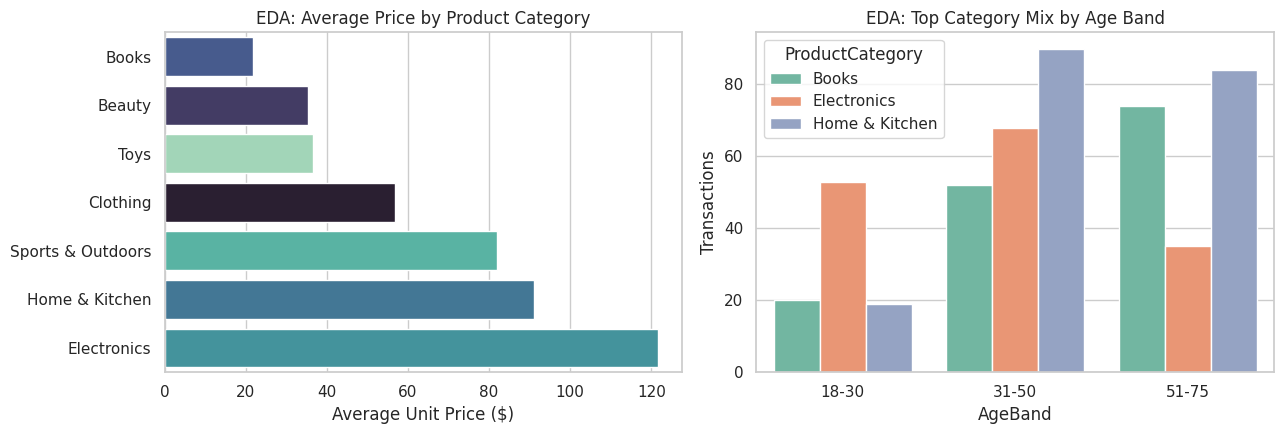

In [56]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

order = df_final.groupby("ProductCategory")["UnitPrice"].mean().sort_values().index
sns.barplot(data=df_final, x="UnitPrice", y="ProductCategory", order=order,
            errorbar=None, hue="ProductCategory", palette="mako", legend=False, ax=axes[0])
axes[0].set_title("EDA: Average Price by Product Category")
axes[0].set_xlabel("Average Unit Price ($)")
axes[0].set_ylabel("")

df_final["AgeBand"] = pd.cut(df_final["CustomerAge"], [17, 30, 50, 75],
                              labels=["18-30", "31-50", "51-75"])
age_cat = df_final.groupby(["AgeBand", "ProductCategory"], observed=True).size().reset_index(name="count")
top3 = df_final["ProductCategory"].value_counts().head(3).index
sns.barplot(data=age_cat[age_cat["ProductCategory"].isin(top3)],
            x="AgeBand", y="count", hue="ProductCategory", palette="Set2", ax=axes[1])
axes[1].set_title("EDA: Top Category Mix by Age Band")
axes[1].set_ylabel("Transactions")

plt.tight_layout()
plt.show()

These two EDA visuals, revisited here, are the foundation the rest of
the project builds on: category drives price (left), and category
preference shifts with customer age (right) — both patterns that later
showed up as the dominant signal in the regression, classification, and
association-rule results above.

## 4.3 Practical Recommendations

Based on the combined results from all four techniques, the following
actions are recommended:

1. **Prioritize category-level pricing and merchandising strategy.**
   Since `ProductCategory` is the single strongest predictor across
   regression, classification, and association rules, category-level
   decisions (pricing tiers, promotional calendars, inventory allocation)
   will have more business impact than customer-demographic-level
   personalization.
2. **Launch a two-tier loyalty program aligned with the K-Means segments.**
   The "high-value/diverse-category" cluster (142 customers, ~$1,122 average
   total spend) should be prioritized for a VIP/loyalty tier, while the
   "casual/single-category" cluster (184 customers) is a better fit for
   re-engagement offers and cross-category discovery incentives.
3. **Use the classification model to flag likely high-value transactions
   in real time.** Even at modest accuracy (~0.60), the Naive Bayes model
   provides a usable signal for prioritizing customer service attention or
   real-time offer targeting, better than no model at all.
4. **Act on the strongest association rules with cross-category bundling.**
   The `Home & Kitchen` / `Beauty` / `Books` cluster of rules (lift up to
   ~1.62) suggests concrete bundle or "frequently bought together"
   opportunities to test, starting with the highest-lift pairs.
5. **Treat all model outputs as directional, not deterministic.** Given the
   modest R2/accuracy figures throughout, these models should support human
   decision-making (e.g., which segment to target first) rather than fully
   automate decisions (e.g., auto-denying a discount to a "low-value"
   prediction).

## 4.4 Ethical Considerations

- **Data privacy:** The dataset used in this project is **synthetically
  generated** specifically for this coursework and contains no real
  customer information — there is no re-identification risk. In a
  real-world deployment of this pipeline, customer age, gender, state, and
  purchase history are personal data and would need to be handled under
  applicable privacy regulations (e.g., consent for use, data minimization,
  secure storage, and a defined retention period), and any customer-level
  model outputs (e.g., cluster assignment, high-value prediction) should be
  access-controlled rather than broadly shared.
- **Fairness and bias:** The classification and clustering models use
  `Gender`, `CustomerAge`, and `State` as predictive features. Even though
  this project's data is synthetic, in a real deployment this raises a
  fairness question: if a model's "high-value customer" predictions or
  loyalty-tier assignments systematically favor or disadvantage a
  demographic group, that could translate into inequitable treatment (e.g.,
  differential promotional offers by age or region). Before any real-world
  use, model outcomes should be audited by demographic subgroup, not just
  in aggregate, to check for disparate impact.
- **Bias introduced by the synthetic data design itself:** because this
  dataset was constructed with an explicit age-to-category-preference rule
  (see Deliverable 1) to give the models genuine signal to learn from, the
  classification and clustering results **partly reflect a pattern the
  data was designed to contain**, not an independently discovered fact
  about real customers. This is an appropriate and disclosed limitation for
  a coursework dataset, but it underscores a general risk: models are only
  as fair and accurate as the data-generating process behind them, and a
  real deployment would need to validate that any observed
  age/category or gender/spending relationship reflects genuine customer
  behavior rather than an artifact of how the training data was collected.
- **Association rule mining and profiling risk:** market-basket rules are
  generally lower-risk than individual-level predictions since they
  describe aggregate co-purchase patterns rather than predictions about a
  specific person. Even so, using them to target individual customers
  (e.g., "this customer bought Beauty, so market Home & Kitchen to them")
  edges toward individual profiling and should follow the same consent and
  transparency principles as any other targeted marketing.
- **Steps taken in this project to address these concerns:** (1) used a
  fully synthetic dataset with no real personal information; (2) excluded
  `Quantity`/`UnitPrice` from predictive features specifically to avoid a
  misleadingly inflated (leaked) model that would misrepresent true
  predictive power; (3) reported all model metrics honestly, including
  modest R2/accuracy figures, rather than selectively presenting only
  favorable results; (4) explicitly flagged the synthetic data's built-in
  age/category relationship as a disclosed limitation rather than
  presenting it as an organic discovery.

## 4.5 Key Takeaways and Future Improvements

**Key takeaways:**
- A single retail transactions dataset can support a full data mining
  pipeline — regression, classification, clustering, and association rule
  mining — each technique surfacing a consistent, mutually reinforcing
  story centered on `ProductCategory`.
- Deliberately excluding features that would leak the target (`Quantity`,
  `UnitPrice`) produced more honest, lower R2/accuracy numbers than an
  unconstrained model would — and that honesty was itself a key insight,
  not a shortcoming.
- Customer segmentation (clustering) revealed that **spend and engagement**,
  not age or gender, are what separate customer groups in this dataset —
  a more actionable and less demographically sensitive basis for targeting.

**Potential future improvements:**
- Incorporate **real transaction data** (with appropriate privacy
  safeguards) to validate whether the patterns found here generalize beyond
  this synthetic dataset.
- Add **time-series/seasonality modeling** (the current date features are
  simple calendar extracts; a longer history could support actual demand
  forecasting).
- Try **ensemble methods** (Random Forest, Gradient Boosting) for both the
  regression and classification tasks, which often outperform the
  individual models used here.
- Extend the clustering analysis with **more customer-level behavioral
  features** (e.g., time between purchases, return rate, channel
  preference) to find more nuanced segments than the two found here.
- Run **fairness audits** by demographic subgroup before any real-world
  deployment of the classification or clustering models, per the ethical
  considerations above.